# 비즈니스 문제 정의
현재 상황
- 다이캐스팅 공정은 고압·고속으로 용융 금속을 주입하여 정밀 부품을 생산하는 핵심 제조 공정

- 불량 판정이 여전히 육안 검사에 의존

- 불량 발생 후 원인 추적이 어려워 사후 대응 중심의 관리 체계 운영

- 공정 데이터는 축적되고 있으나, 품질 데이터와 효과적으로 연계되지 않음

- 불량 발생 시 재작업·스크랩 비용 증가 및 납기 지연 발생

## 비즈니스 이슈

- 불량 유형별 발생 원인에 대한 정량적 분석 부족

- 실시간 불량 예측 시스템 부재

- 공정 변수와 품질 결과 간 관계 파악 미흡

- Shot 단위 품질 추적 체계 부족

- 불량 발생 후 대응 중심 → 예방 중심 관리 필요

## 해결 필요성

- 머신러닝 기반 불량 예측 시스템 도입

- 주요 공정 변수의 영향력 분석

- 실시간 조기 경보 시스템 구축

- 불량률 감소 → 생산성 향상

- 데이터 기반 공정 최적화 체계 수립

### 주요 질문

"어떤 공정 조건에서 불량이 발생할 가능성이 높은가?"



# 전처리 진행
* 하은님 전처리 참고

In [1]:
# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("C:/Users/hi/OneDrive/바탕 화면/data/DieCasting_Quality_Raw_Data.csv")
df

,Process,Process.1,Process.2,Process.3,Process.4,Process.5,Process.6,Process.7,Process.8,Process.9,Process.10,Process.11,Process.12,Process.13,Process.14,Process.15,Process.16,Sensor,Sensor.1,Sensor.2,Sensor.3,Sensor.4,Sensor.5,Sensor.6,Sensor.7,Sensor.8,Sensor.9,Sensor.10,Sensor.11,Sensor.12,Sensor.13,Defects,Defects.1,Defects.2,Defects.3,Defects.4,Defects.5,Defects.6,Defects.7,Defects.8,Defects.9,Defects.10,Defects.11,Defects.12,Defects.13,Defects.14,Defects.15,Defects.16,Defects.17,Defects.18,Defects.19,Defects.20,Defects.21,Defects.22,Defects.23,Defects.24,Defects.25
0,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
1,1,1,1,0.144,0.17,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,3,9,26.0,10,50,2.71,32.9,18.0,22.0,58.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1002,1,2,0.144,0.17,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2003,1,3,0.144,0.17,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,3004,1,4,0.144,0.17,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7531,7530659,2,659,0.15,0.166,0.21,2.492,265,0.011,17,381,36.2,0.033,595,12.1,2.0,2.0,667.4,6.7,3,9,28.1,10,50,2.62,32.3,18.0,22.0,69.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7532,7531660,2,660,0.144,0.174,0.206,2.514,264,0.011,16,381,36.2,0.041,595,12.1,2.0,2.0,667.8,7.0,3,9,28.1,10,50,2.62,32.2,18.0,22.0,69.5,18.0,22.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7533,7532660,2,660,0.144,0.174,0.206,2.514,264,0.011,16,381,36.2,0.041,595,12.1,2.0,2.0,667.8,7.0,3,9,28.1,10,50,2.62,32.2,18.0,22.0,69.5,18.0,22.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7534,7533661,2,661,0.147,0.174,0.204,2.532,265,0.012,18,382,36.2,0.036,596,12.1,2.0,2.0,668.5,6.8,3,9,28.1,10,50,2.62,32.2,18.0,22.0,69.6,18.0,22.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(7536, 57)

In [4]:
# Defect 변수
defect_cols = df.columns[-26:]

# Sensor 변수
sensor_cols = [col for col in df.columns if "Sensor" in str(col)]

# Process 변수
process_cols = [col for col in df.columns 
                if col not in defect_cols 
                and col not in sensor_cols]

print("Process 변수 개수 :", len(process_cols))
print("Sensor 변수 개수  :", len(sensor_cols))
print("Defect 변수 개수  :", len(defect_cols))

Process 변수 개수 : 17
Sensor 변수 개수  : 14
Defect 변수 개수  : 26


In [5]:
df.info()
# 모든 칼럼이 object타입

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7536 entries, 0 to 7535
Data columns (total 57 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Process     7536 non-null   object
 1   Process.1   7536 non-null   object
 2   Process.2   7536 non-null   object
 3   Process.3   7536 non-null   object
 4   Process.4   7536 non-null   object
 5   Process.5   7536 non-null   object
 6   Process.6   7536 non-null   object
 7   Process.7   7536 non-null   object
 8   Process.8   7536 non-null   object
 9   Process.9   7536 non-null   object
 10  Process.10  7536 non-null   object
 11  Process.11  7536 non-null   object
 12  Process.12  7536 non-null   object
 13  Process.13  7536 non-null   object
 14  Process.14  7536 non-null   object
 15  Process.15  7536 non-null   object
 16  Process.16  7536 non-null   object
 17  Sensor      7536 non-null   object
 18  Sensor.1    7536 non-null   object
 19  Sensor.2    7536 non-null   object
 20  Sensor.3

In [6]:
df.describe()

,Process,Process.1,Process.2,Process.3,Process.4,Process.5,Process.6,Process.7,Process.8,Process.9,Process.10,Process.11,Process.12,Process.13,Process.14,Process.15,Process.16,Sensor,Sensor.1,Sensor.2,Sensor.3,Sensor.4,Sensor.5,Sensor.6,Sensor.7,Sensor.8,Sensor.9,Sensor.10,Sensor.11,Sensor.12,Sensor.13,Defects,Defects.1,Defects.2,Defects.3,Defects.4,Defects.5,Defects.6,Defects.7,Defects.8,Defects.9,Defects.10,Defects.11,Defects.12,Defects.13,Defects.14,Defects.15,Defects.16,Defects.17,Defects.18,Defects.19,Defects.20,Defects.21,Defects.22,Defects.23,Defects.24,Defects.25
count,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7446,7446,7446,7446,7446,7446,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536,7536
unique,7536,3,1272,34,28,46,320,23,19,25,43,62,17,66,33,8,9,738,27,2,2,24,2,2,23,68,2,2,218,2,2,4,3,4,5,4,3,4,3,3,3,3,3,2,4,4,4,4,2,3,4,3,3,3,2,2,3
top,id,1,44,0.144,0.168,0.182,2.524,265,0.008,11,257,36.1,0.044,596,12.1,2.0,0.8,687.0,6.2,3,9,26.5,10,50,2.74,32.0,18.0,22.0,62.0,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
freq,1,4207,12,1546,2540,577,204,2639,2704,1671,1004,848,1322,1492,1418,3192,3349,49,870,7535,7535,801,7535,7535,1003,1358,7445,7445,162,7445,7445,7038,7463,7362,7314,7346,7528,7427,7531,7533,7534,7533,7530,7535,7355,7528,7404,7380,7535,7531,7471,7527,7530,7533,7535,7535,7534


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7536 entries, 0 to 7535
Data columns (total 57 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Process     7536 non-null   object
 1   Process.1   7536 non-null   object
 2   Process.2   7536 non-null   object
 3   Process.3   7536 non-null   object
 4   Process.4   7536 non-null   object
 5   Process.5   7536 non-null   object
 6   Process.6   7536 non-null   object
 7   Process.7   7536 non-null   object
 8   Process.8   7536 non-null   object
 9   Process.9   7536 non-null   object
 10  Process.10  7536 non-null   object
 11  Process.11  7536 non-null   object
 12  Process.12  7536 non-null   object
 13  Process.13  7536 non-null   object
 14  Process.14  7536 non-null   object
 15  Process.15  7536 non-null   object
 16  Process.16  7536 non-null   object
 17  Sensor      7536 non-null   object
 18  Sensor.1    7536 non-null   object
 19  Sensor.2    7536 non-null   object
 20  Sensor.3

In [8]:
df = pd.read_csv("C:/Users/hi/OneDrive/바탕 화면/data/DieCasting_Quality_Raw_Data.csv", header=[0,1])
df.head()

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                        \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
0               214           0.008                 10             258   
1               217           0.008                 11             257   
2               214           0.008                 11             257   
3               217           0.008                 11             257   
4               217           0.008                 12             257   

                                                                           \
  Cycle_Time  Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7               0.044             1037        7.8          0.7   
1       20.7               0.044             1052        7.8          0.7   
2       20.8               0.041             1037        7.8          0.7   
3       20.7               0.043             1051        7.8          0.7   
4       20.7               0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0        

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float64
 12  (Process,  Pressure_Rise_Time)  75

In [10]:
# 컬럼명 중 첫번째 행을 기준으로 컬럼 분리
process_cols = [col for col in df.columns if col[0] == 'Process']
sensor_cols = [col for col in df.columns if col[0] == 'Sensor']
defects_cols = [col for col in df.columns if col[0] == 'Defects']

# 데이터 프레임 생성
df_process = df[process_cols].copy()
df_sensor = df[sensor_cols].copy()
df_defects = df[defects_cols].copy()

print("파일 분리")
print(f"Process: 컬럼 {len(process_cols)}개")
print(f"Sensor: 컬럼 {len(sensor_cols)}개")
print(f"Defects: 컬럼 {len(defects_cols)}개")

파일 분리
Process: 컬럼 17개
Sensor: 컬럼 14개
Defects: 컬럼 26개


In [11]:
def show_df_info(df, df_name):
    
    print(f"{'='*60}")
    print(f"{df_name} 데이터프레임 정보")
    print(f"{'='*60}")
    
    # .values: Numpy 배열로 반환
    # 각각의 값이 인덱스가 안맞아서 DataFrame을 만들 때 충돌되지 않도록 하기 위해서 사용
    info_df = pd.DataFrame({
        'Column Name': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null_Cnt': df.count().values,
        'Null_Cnt': df.isnull().sum().values,
        'Null_pct(%)': (df.isnull().sum() / len(df) * 100).round(2).values
    })
    
    display(info_df)
    return info_df

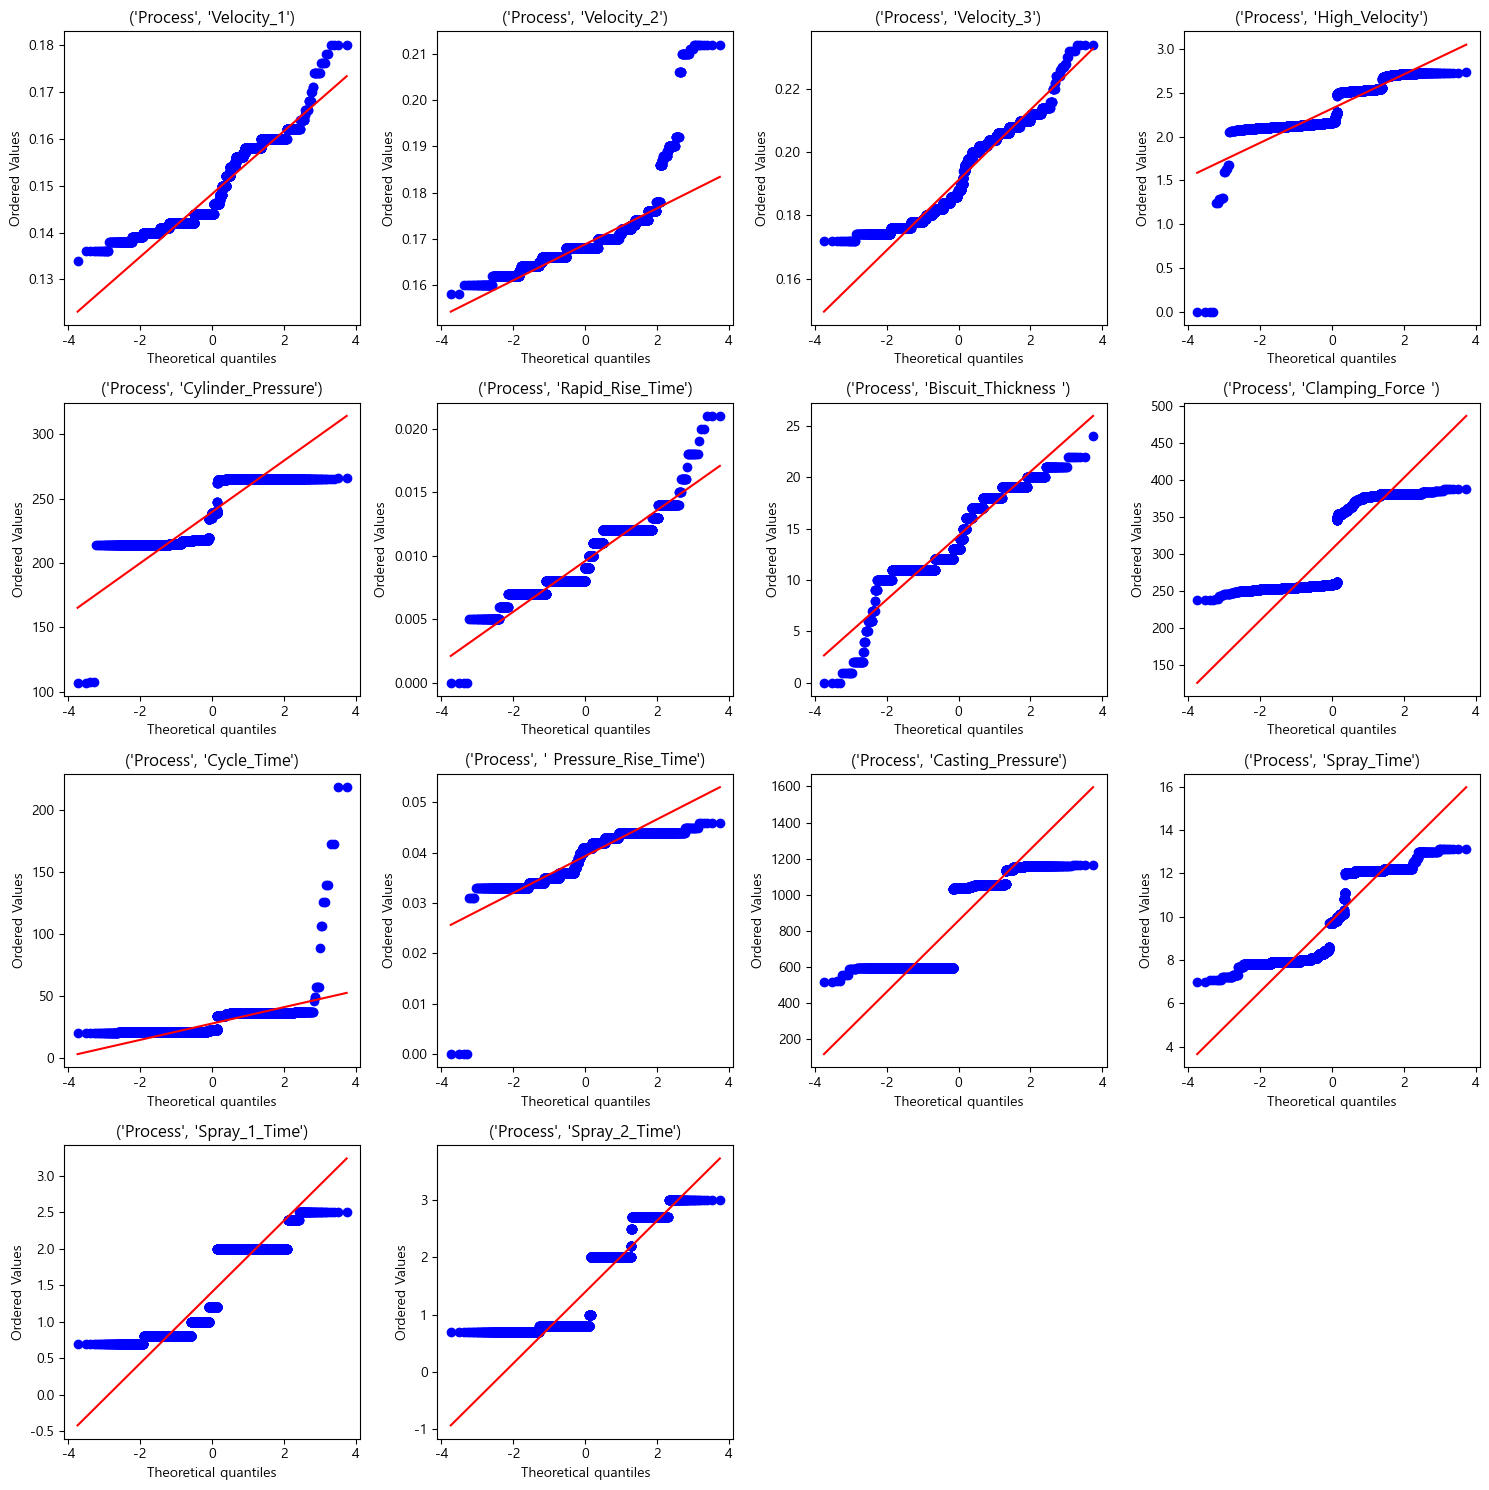

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(4, 4, figsize=(15,15))


stats.probplot(df[process_cols[3]].dropna(), dist="norm", plot=axes[0,0])
axes[0,0].set_title(process_cols[3])

stats.probplot(df[process_cols[4]].dropna(), dist="norm", plot=axes[0,1])
axes[0,1].set_title(process_cols[4])

stats.probplot(df[process_cols[5]].dropna(), dist="norm", plot=axes[0,2])
axes[0,2].set_title(process_cols[5])

stats.probplot(df[process_cols[6]].dropna(), dist="norm", plot=axes[0,3])
axes[0,3].set_title(process_cols[6])

stats.probplot(df[process_cols[7]].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title(process_cols[7])

stats.probplot(df[process_cols[8]].dropna(), dist="norm", plot=axes[1,1])
axes[1,1].set_title(process_cols[8])

stats.probplot(df[process_cols[9]].dropna(), dist="norm", plot=axes[1,2])
axes[1,2].set_title(process_cols[9])

stats.probplot(df[process_cols[10]].dropna(), dist="norm", plot=axes[1,3])
axes[1,3].set_title(process_cols[10])

stats.probplot(df[process_cols[11]].dropna(), dist="norm", plot=axes[2,0])
axes[2,0].set_title(process_cols[11])

stats.probplot(df[process_cols[12]].dropna(), dist="norm", plot=axes[2,1])
axes[2,1].set_title(process_cols[12])

stats.probplot(df[process_cols[13]].dropna(), dist="norm", plot=axes[2,2])
axes[2,2].set_title(process_cols[13])

stats.probplot(df[process_cols[14]].dropna(), dist="norm", plot=axes[2,3])
axes[2,3].set_title(process_cols[14])

# 4행 (14개라서 2칸만 사용)
stats.probplot(df[process_cols[15]].dropna(), dist="norm", plot=axes[3,0])
axes[3,0].set_title(process_cols[15])

stats.probplot(df[process_cols[16]].dropna(), dist="norm", plot=axes[3,1])
axes[3,1].set_title(process_cols[16])

# 남는 칸 제거
axes[3,2].set_visible(False)
axes[3,3].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(4,4, figsize=(15,15))
axes = axes.flatten()

for i, col in enumerate(process_cols[3:17]):
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

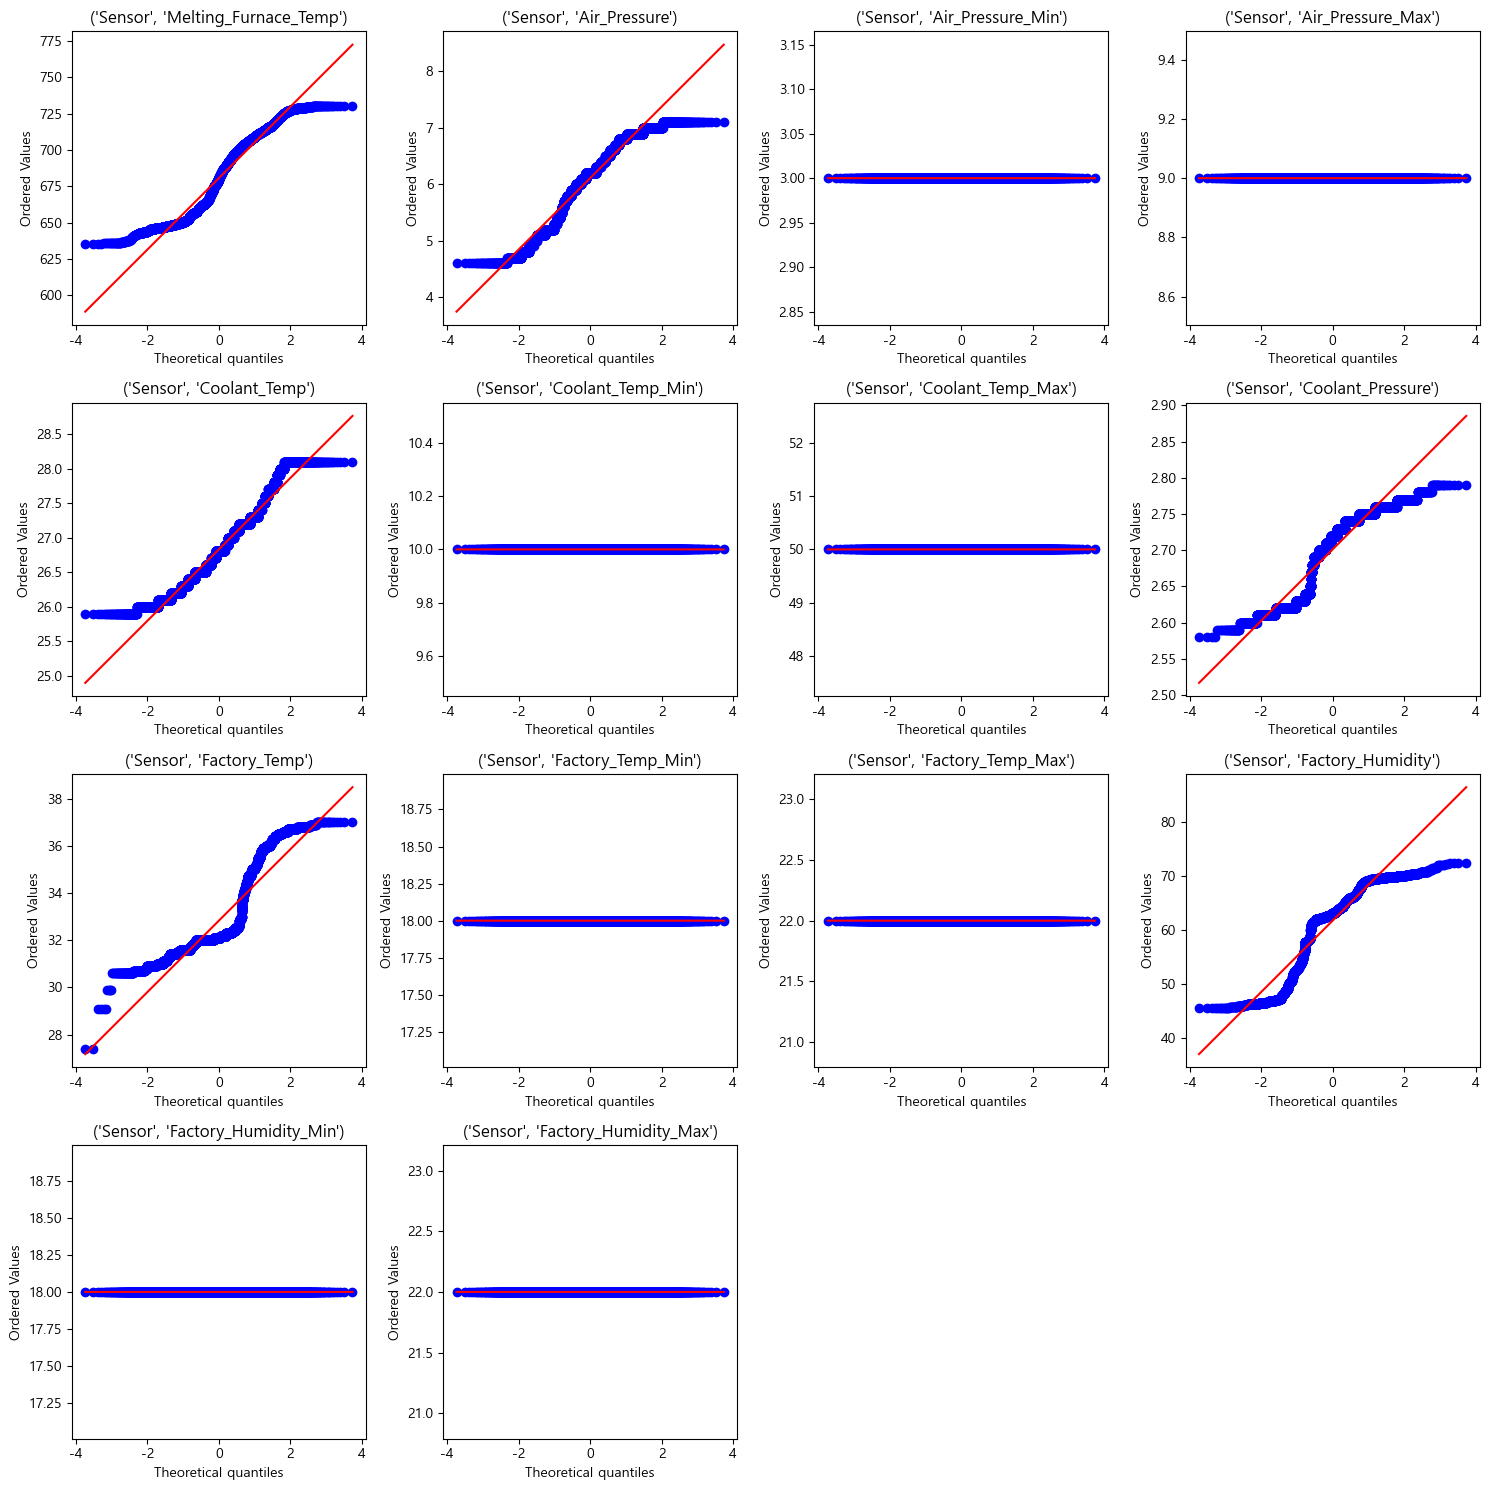

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(4, 4, figsize=(15,15))

# 1행
stats.probplot(df[sensor_cols[0]].dropna(), dist="norm", plot=axes[0,0])
axes[0,0].set_title(sensor_cols[0])

stats.probplot(df[sensor_cols[1]].dropna(), dist="norm", plot=axes[0,1])
axes[0,1].set_title(sensor_cols[1])

stats.probplot(df[sensor_cols[2]].dropna(), dist="norm", plot=axes[0,2])
axes[0,2].set_title(sensor_cols[2])

stats.probplot(df[sensor_cols[3]].dropna(), dist="norm", plot=axes[0,3])
axes[0,3].set_title(sensor_cols[3])

# 2행
stats.probplot(df[sensor_cols[4]].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title(sensor_cols[4])

stats.probplot(df[sensor_cols[5]].dropna(), dist="norm", plot=axes[1,1])
axes[1,1].set_title(sensor_cols[5])

stats.probplot(df[sensor_cols[6]].dropna(), dist="norm", plot=axes[1,2])
axes[1,2].set_title(sensor_cols[6])

stats.probplot(df[sensor_cols[7]].dropna(), dist="norm", plot=axes[1,3])
axes[1,3].set_title(sensor_cols[7])

# 3행
stats.probplot(df[sensor_cols[8]].dropna(), dist="norm", plot=axes[2,0])
axes[2,0].set_title(sensor_cols[8])

stats.probplot(df[sensor_cols[9]].dropna(), dist="norm", plot=axes[2,1])
axes[2,1].set_title(sensor_cols[9])

stats.probplot(df[sensor_cols[10]].dropna(), dist="norm", plot=axes[2,2])
axes[2,2].set_title(sensor_cols[10])

stats.probplot(df[sensor_cols[11]].dropna(), dist="norm", plot=axes[2,3])
axes[2,3].set_title(sensor_cols[11])

# 4행 
stats.probplot(df[sensor_cols[12]].dropna(), dist="norm", plot=axes[3,0])
axes[3,0].set_title(sensor_cols[12])

stats.probplot(df[sensor_cols[13]].dropna(), dist="norm", plot=axes[3,1])
axes[3,1].set_title(sensor_cols[13])

# 남는 칸 제거
axes[3,2].set_visible(False)
axes[3,3].set_visible(False)

plt.tight_layout()
plt.show()

Velocity Columns: [('Process', 'Velocity_1'), ('Process', 'Velocity_2'), ('Process', 'Velocity_3'), ('Process', 'High_Velocity')]
Velocity 상관계수:
                          Process                                    
                      Velocity_1 Velocity_2 Velocity_3 High_Velocity
Process Velocity_1      1.000000   0.259123   0.792873      0.760578
        Velocity_2      0.259123   1.000000   0.244407      0.005660
        Velocity_3      0.792873   0.244407   1.000000      0.824179
        High_Velocity   0.760578   0.005660   0.824179      1.000000


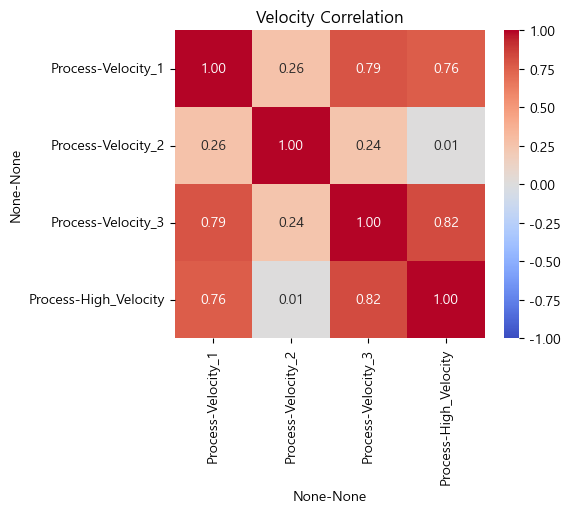

In [ ]:
# Velocity 상관관계
velocity_cols = [col for col in df.columns if 'Velocity' in col[1]]
print("Velocity Columns:", velocity_cols)

# 해당 컬럼 선택
velocity_corr = df[velocity_cols].corr()
print("Velocity 상관계수:\n", velocity_corr)

# 히트맵 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(velocity_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Velocity Correlation")
plt.show()

Spray Columns: [('Process', 'Spray_Time'), ('Process', 'Spray_1_Time'), ('Process', 'Spray_2_Time')]
Spray 상관계수:
                         Process                          
                     Spray_Time Spray_1_Time Spray_2_Time
Process Spray_Time     1.000000     0.933181     0.800236
        Spray_1_Time   0.933181     1.000000     0.937847
        Spray_2_Time   0.800236     0.937847     1.000000


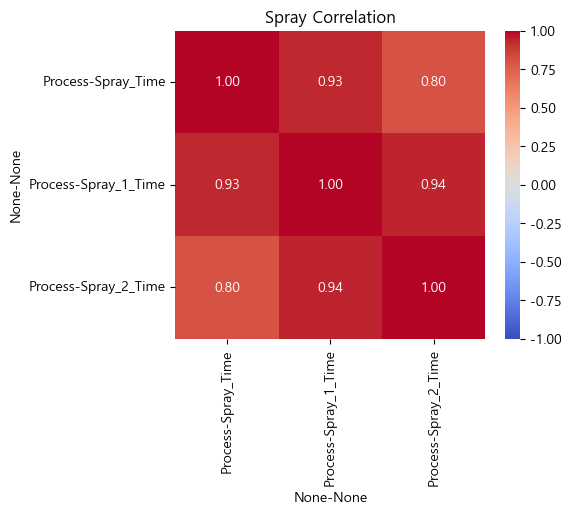

In [ ]:
# Spray 상관관계
velocity_cols = [col for col in df.columns if 'Spray' in col[1]]
print("Spray Columns:", velocity_cols)

# 해당 컬럼 선택
velocity_corr = df[velocity_cols].corr()
print("Spray 상관계수:\n", velocity_corr)

# 히트맵 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(velocity_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spray Correlation")
plt.show()

Defect Columns: [('Defects', 'Short_Shot_1'), ('Defects', 'Bubble_1'), ('Defects', 'Exfoliation_1'), ('Defects', 'Blow_Hole_1'), ('Defects', 'Stain_1'), ('Defects', 'Dent_1'), ('Defects', 'Deformation_1'), ('Defects', 'Contamination_1'), ('Defects', 'Impurity_1'), ('Defects', 'Crack_1'), ('Defects', 'Scratch_1'), ('Defects', 'Buring_Mark_1'), ('Defects', 'Inclusions_1'), ('Defects', 'Short_Shot_2'), ('Defects', 'Bubble_2'), ('Defects', 'Exfoliation_2'), ('Defects', 'Blow_Hole_2'), ('Defects', 'Stain_2'), ('Defects', 'Dent_2'), ('Defects', 'Deformation_2'), ('Defects', 'Contamination_2'), ('Defects', 'Impurity_2'), ('Defects', 'Crack_2'), ('Defects', 'Scratch_2'), ('Defects', 'Buring_Mark_2'), ('Defects', 'Inclusions_2')]
Exfoliation Columns: [('Defects', 'Exfoliation_1'), ('Defects', 'Exfoliation_2')]
Exfoliation vs Other Defects 상관계수:

                           Defects                                      \
                      Short_Shot_1  Bubble_1 Exfoliation_1 Blow_Hole_1   
Def

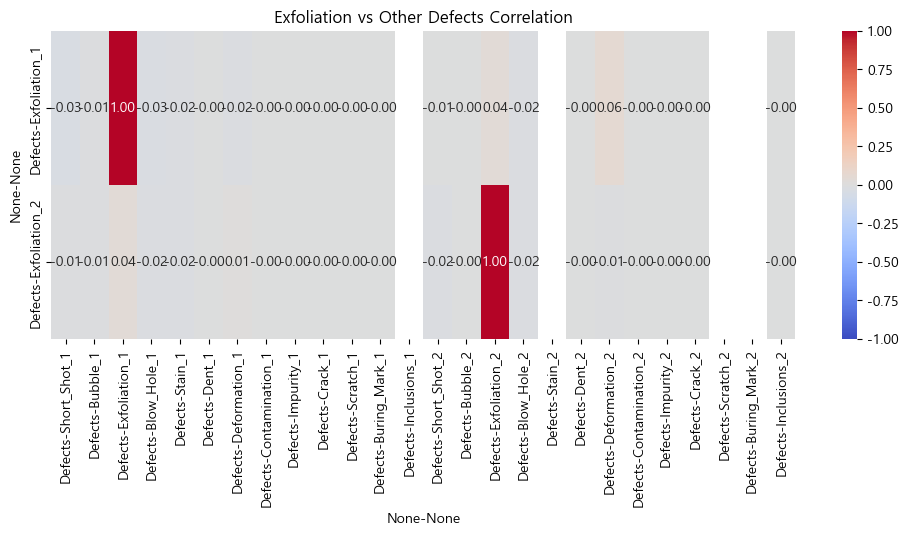

In [ ]:
# Exfoliation과 다른 Defects 상관관계
defect_cols = [col for col in df.columns if col[0] == 'Defects']
print("Defect Columns:", defect_cols)

# Exfoliation 컬럼만 선택
exfoliation_cols = [col for col in defect_cols if 'Exfoliation' in col[1]]
print("Exfoliation Columns:", exfoliation_cols)

# Defects 상관계수 전체 계산
defect_corr = df[defect_cols].corr()

# Exfoliation과 다른 Defects의 상관관계만 보기
exfoliation_corr = defect_corr.loc[exfoliation_cols]

print("Exfoliation vs Other Defects 상관계수:\n")
print(exfoliation_corr)

# 히트맵 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
sns.heatmap(exfoliation_corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1)

plt.title("Exfoliation vs Other Defects Correlation")
plt.show()

In [ ]:
import pandas as pd

# Defects 관련 컬럼만 뽑기 (컬럼명이 문자열인 경우)
defect_cols = [c for c in df.columns if "Defects" in str(c)]
defects_df_clean2 = df[defect_cols].copy()

# 혹시 결측이 있으면 0으로
defects_df_clean2 = defects_df_clean2.fillna(0)

In [ ]:
# 1) 그룹 정의
groups = {
    "Surface_Defect": ["Stain", "Dent", "Scratch", "Burning_Mark"],                                     # 표면 불량
    "Structural_Defect": ["Short_Shot", "Bubble", "Blow_Hole", "Deformation", "Crack", "Exfoliation"],  # 구조 불량
    "Contamination_Defect": ["Contamination", "Impurity", "Inclusions"],                                # 이물질 포함 불량
}

# 2) 그룹 컬럼 만들기 + 값 합치기 (defects_df_clean2 기준)
group_df_sum = pd.DataFrame(index=defects_df_clean2.index)

for g, members in groups.items():
    group_df_sum[g] = defects_df_clean2.reindex(columns=members, fill_value=0).sum(axis=1).astype(int)

# 3) 0~4 개수/비율 테이블
n = len(group_df_sum)

dist_by_group = pd.DataFrame({
    "0_count": (group_df_sum == 0).sum(),
    "1_count": (group_df_sum == 1).sum(),
    "2_count": (group_df_sum == 2).sum(),
    "3_count": (group_df_sum == 3).sum(),
    "4_count": (group_df_sum == 4).sum(),
    "5plus_count": (group_df_sum >= 5).sum(),
})

dist_by_group["0_rate(%)"] = (dist_by_group["0_count"] / n * 100).round(2)
dist_by_group["1_rate(%)"] = (dist_by_group["1_count"] / n * 100).round(2)
dist_by_group["2_rate(%)"] = (dist_by_group["2_count"] / n * 100).round(2)
dist_by_group["3_rate(%)"] = (dist_by_group["3_count"] / n * 100).round(2)
dist_by_group["4_rate(%)"] = (dist_by_group["4_count"] / n * 100).round(2)
dist_by_group["5plus_rate(%)"] = (dist_by_group["5plus_count"] / n * 100).round(2)

# 4) 네 기준대로 정렬
dist_by_group = dist_by_group.sort_values("5plus_rate(%)", ascending=False)

display(dist_by_group)

,0_count,1_count,2_count,3_count,4_count,5plus_count,0_rate(%),1_rate(%),2_rate(%),3_rate(%),4_rate(%),5plus_rate(%)
Surface_Defect,7535,0,0,0,0,0,100.0,0.0,0.0,0.0,0.0,0.0
Structural_Defect,7535,0,0,0,0,0,100.0,0.0,0.0,0.0,0.0,0.0
Contamination_Defect,7535,0,0,0,0,0,100.0,0.0,0.0,0.0,0.0,0.0
